# Packages

In [1]:
import os
import glob
import re
from datetime import timedelta, datetime

import hist
import uproot

import dask
import awkward as ak
import dask_awkward as da
import dask.dataframe as dd
import dask_histogram as dh
from dask.diagnostics import ProgressBar

import boost_histogram as bh

from particle import Particle, ParticleNotFound

import numpy as np
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd


import time

import plotly.graph_objects as go


# Monitoring of kernel

In [24]:
""" from dask.distributed import Client
import re
import socket

client = Client()

print(f"=== KERNEL NODE INFO ===")
print(f"Node/Hostname: {socket.gethostname()}")

# Client-Info anzeigen:
print(f"Scheduler address: {client.scheduler.address}")
print(f"Dashboard link: {client.dashboard_link}")

# Ports extrahieren:
scheduler_address = client.scheduler.address
dashboard_link = client.dashboard_link

# Port-Nummern aus den URLs extrahieren:
scheduler_port = re.findall(r':(\d+)', scheduler_address)[0]
dashboard_port = re.findall(r':(\d+)', dashboard_link)[0]

print(f"\n=== PORT FORWARDING INFO ===")
print(f"Scheduler Port: {scheduler_port}")
print(f"Dashboard Port: {dashboard_port}")

print(f"\n=== SSH COMMAND ===")
print(f"ssh -L {scheduler_port}:localhost:{scheduler_port} -L {dashboard_port}:localhost:{dashboard_port} -N bkoberg@palma")

print(f"\n=== DASHBOARD URL (nach Port-Forwarding) ===")
print(f"http://localhost:{dashboard_port}") """

' from dask.distributed import Client\nimport re\nimport socket\n\nclient = Client()\n\nprint(f"=== KERNEL NODE INFO ===")\nprint(f"Node/Hostname: {socket.gethostname()}")\n\n# Client-Info anzeigen:\nprint(f"Scheduler address: {client.scheduler.address}")\nprint(f"Dashboard link: {client.dashboard_link}")\n\n# Ports extrahieren:\nscheduler_address = client.scheduler.address\ndashboard_link = client.dashboard_link\n\n# Port-Nummern aus den URLs extrahieren:\nscheduler_port = re.findall(r\':(\\d+)\', scheduler_address)[0]\ndashboard_port = re.findall(r\':(\\d+)\', dashboard_link)[0]\n\nprint(f"\n=== PORT FORWARDING INFO ===")\nprint(f"Scheduler Port: {scheduler_port}")\nprint(f"Dashboard Port: {dashboard_port}")\n\nprint(f"\n=== SSH COMMAND ===")\nprint(f"ssh -L {scheduler_port}:localhost:{scheduler_port} -L {dashboard_port}:localhost:{dashboard_port} -N bkoberg@palma")\n\nprint(f"\n=== DASHBOARD URL (nach Port-Forwarding) ===")\nprint(f"http://localhost:{dashboard_port}") '

In [25]:
""" print(f"\n=== WORKER INFO ===")
for worker_id, worker_info in client.scheduler_info()['workers'].items():
    print(f"Worker: {worker_id}")
    print(f"  CPU Cores: {worker_info['nthreads']}")
    print(f"  Memory: {worker_info['memory_limit'] / 1024**3:.1f} GB")
    print(f"  Tasks: {worker_info.get('executing', 0)} executing, {worker_info.get('in_memory', 0)} in memory") """


' print(f"\n=== WORKER INFO ===")\nfor worker_id, worker_info in client.scheduler_info()[\'workers\'].items():\n    print(f"Worker: {worker_id}")\n    print(f"  CPU Cores: {worker_info[\'nthreads\']}")\n    print(f"  Memory: {worker_info[\'memory_limit\'] / 1024**3:.1f} GB")\n    print(f"  Tasks: {worker_info.get(\'executing\', 0)} executing, {worker_info.get(\'in_memory\', 0)} in memory") '

****
# Observing and controlling

## While sim is running

In [36]:
log_dir = "/home/b/bkoberg/logs"
out_files = glob.glob(os.path.join(log_dir, "*.out"))

rows = []

for i, file in enumerate(out_files):
    with open(file, "r") as f:
        lines = f.readlines()

        perc = re.search(r"(\d+)%", lines[-1].strip())

        begin = re.search(r"(\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[455].strip())
        now = re.search(r"(\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[-1].strip())
        end = re.search(r"ETA: (\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[-1].strip())

        fmt = "%Y-%m-%d %H-%M-%S"
        dt_start = datetime.strptime(begin.group(1), fmt) if begin else None
        dt_now = datetime.strptime(now.group(1), fmt) if now else None
        dt_ende = datetime.strptime(end.group(1), fmt) if end else None

        rows.append({
            "File": os.path.basename(file),
            "Progress": perc.group(1) if perc else None,
            "begin": dt_start,
            "end": dt_ende,
            "now": dt_now,
            "Time to go": (dt_ende - dt_now) if (dt_ende and dt_now) else None,
            "Total Time": (dt_ende - dt_start) if (dt_ende and dt_start) else None
        })

df = pd.DataFrame(rows)

max_time = df.loc[df["Time to go"].idxmax()]
max_total_time = df.loc[df["Total Time"].idxmax()]
print("=== MAX TIME TO GO ===")
print(max_time)
print("\n=== MAX TOTAL TIME ===")
print(max_total_time)

df = df[df["Time to go"].notnull()]
df.sort_values(by="Time to go", inplace=True, ascending=False)
df

=== MAX TIME TO GO ===
File          simulation-33225737.out
Progress                           45
begin             2025-07-10 10:39:08
end               2025-07-11 03:47:33
now               2025-07-10 18:11:53
Time to go            0 days 09:35:40
Total Time            0 days 17:08:25
Name: 477, dtype: object

=== MAX TOTAL TIME ===
File          simulation-33225737.out
Progress                           45
begin             2025-07-10 10:39:08
end               2025-07-11 03:47:33
now               2025-07-10 18:11:53
Time to go            0 days 09:35:40
Total Time            0 days 17:08:25
Name: 477, dtype: object


,File,Progress,begin,end,now,Time to go,Total Time
477,simulation-33225737.out,45,2025-07-10 10:39:08,2025-07-11 03:47:33,2025-07-10 18:11:53,0 days 09:35:40,0 days 17:08:25
612,simulation-33225710.out,45,2025-07-10 10:37:58,2025-07-11 03:30:32,2025-07-10 18:10:23,0 days 09:20:09,0 days 16:52:34
105,simulation-33225747.out,45,2025-07-10 10:39:07,2025-07-11 03:31:33,2025-07-10 18:12:03,0 days 09:19:30,0 days 16:52:26
212,simulation-33225817.out,45,2025-07-10 10:49:56,2025-07-11 03:27:07,2025-07-10 18:10:22,0 days 09:16:45,0 days 16:37:11
466,simulation-33225593.out,46,2025-07-10 10:31:57,2025-07-11 03:24:33,2025-07-10 18:10:27,0 days 09:14:06,0 days 16:52:36
...,...,...,...,...,...,...,...
339,simulation-33225556.out,57,2025-07-10 10:28:16,2025-07-11 00:11:13,2025-07-10 18:12:12,0 days 05:59:01,0 days 13:42:57
281,simulation-33225549.out,57,2025-07-10 10:28:02,2025-07-11 00:10:21,2025-07-10 18:11:33,0 days 05:58:48,0 days 13:42:19
680,simulation-33225668.out,57,2025-07-10 10:33:30,2025-07-11 00:05:58,2025-07-10 18:12:08,0 days 05:53:50,0 days 13:32:28
583,simulation-33225755.out,57,2025-07-10 10:37:22,2025-07-10 23:59:54,2025-07-10 18:11:43,0 days 05:48:11,0 days 13:22:32


## After controle

In [2]:
log_dir = "/home/b/bkoberg/logs"
out_files = glob.glob(os.path.join(log_dir, "*.out"))

rows = []

for i, file in enumerate(out_files):
    with open(file, "r") as f:
        lines = f.readlines()

        

        exit_code_match = re.search(r"State:\s*(.*)", lines[-8].strip())
        if not exit_code_match:
            exit_code_match = re.search(r"State:\s*(.*)", lines[-9].strip())

        time_match = re.search(r"(\d{1,2}:\d{1,2}:\d{1,2})", lines[-4].strip())
        time = datetime.strptime(time_match.group(1), "%H:%M:%S") if time_match else None

        rows.append({
            "File": os.path.basename(file),
            "Exit Code": exit_code_match.group(1) if exit_code_match else None,
            "Lines": len(lines),
            "Time": time,
        })

df = pd.DataFrame(rows)

df_wak = df[df['Exit Code'] != 'COMPLETED (exit code 0)'] # either new datei or RUNNING

df_wak


,File,Exit Code,Lines,Time
40,simulation-33370385.out,RUNNING,873,NaT
111,simulation-33450484.out,None,859,NaT
263,simulation-33450901.out,RUNNING,873,NaT
721,simulation-33450891.out,RUNNING,873,NaT
774,simulation-33370084.out,None,878,NaT
821,simulation-33370270.out,RUNNING,873,NaT


***
# Sachen die ich actually brauche

## Loading using dask

In [4]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
path_Version = "4_7e82d44"
path_Material = "Polyethylen25"  
path_length = "45cm"

min_data_file_size = 5 * 1024 * 1024
data_files = glob.glob(f"{data_path}/{path_Version}/{path_Material}/{path_length}/*.root")
print(f"Found {len(data_files)} files matching pattern '{path_length}' in '{data_path}/{path_Version}/{path_Material}/{path_length}/'.")

uproot_files = [{f:"events/events"} for f in data_files if os.path.getsize(f) > min_data_file_size]
print(f"Available keys in uproot files: {uproot.open(uproot_files[0]).keys()}")

Found 500 files matching pattern '45cm' in '/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/4_7e82d44/Polyethylen25/45cm/'.
Available keys in uproot files: ['eventid', 'type_pri', 'type_pri_id', 'e_pri', 'xp_pri', 'yp_pri', 'zp_pri', 'cx_pri', 'cy_pri', 'cz_pri', 'vol_pri', 'vol_pri_hash', 'NSave', 'Save_flag', 'Save_desc', 'Save_type', 'Save_x', 'Save_y', 'Save_z', 'Save_cx', 'Save_cy', 'Save_cz', 'Save_e', 'Save_t', 'Save_eventid', 'Save_trackid', 'Save_volume', 'NNAct', 'NAct_eventid', 'NAct_trackid', 'NAct_parentid', 'NAct_t', 'NAct_volume', 'NAct_volume_hash', 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_process_name', 'NAct_process_category', 'NAct_process_ID', 'NAct_particle_name', 'NAct_particle_lifetime', 'NAct_particle_id', 'NAct_particle_atomicnumber', 'NAct_particle_mass', 'NAct_particle_excitationEnergy']


In [5]:
num = 500
uproot_files = uproot_files[:num]

In [6]:
arr = uproot.dask(uproot_files, filter_name=uproot.open(uproot_files[0]).keys(), allow_missing=True, step_size="110MB")
arr['type_pri_id'] = ak.flatten(arr['type_pri_id'])

arr = arr[arr['type_pri_id'] == 2112]
arr


dask.awkward<getitem, npartitions=9500>

In [7]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}')

In [8]:
data_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data'
if not os.path.exists(f'{data_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{data_path}/{path_Version}/{path_Material}/{path_length}')

FORCE_OVERWRITE = False

### Meta-Daten und Tabellen für IDs

In [9]:
file = f"/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/{path_Version}/NoAbsorber/10cm/0.root"
rfile = uproot.open(file)

print(f"The file contains {len(rfile.keys())} keys:")
for key in rfile.keys():
    print(f"  {key}")

print(f"\nExecuted with G4VERSION {rfile['G4VERSION_TAG'].member('fTitle')}")
print(f"Total runtime: {rfile['G4RUNTIME'].member('fVal')} seconds")
print(f"Number of events: {rfile['events/nbevents'].member('fVal')}")

print(f"\nUsing the macros:")
for macro in rfile["macros"].keys():
    print(f"--> {rfile['macros'][macro].member('fName')}")
    print(f"    File content hidden for brevity ...")
    for line in rfile["macros"][macro].member('fTitle').splitlines():
        print(f"    {line}")
    print("")

The file contains 32 keys:
  G4VERSION_TAG;1
  MC_TAG;1
  MCVERSION_TAG;1
  macros;1
  macros/preinit.mac;1
  macros/det_setup.mac;1
  macros/src_neutron.mac;1
  tables;1
  tables/neutronXS_G4_AIR;1
  tables/neutronXS_G4_WATER;1
  tables/neutronXS_G4_Galactic;1
  tables/neutronXS_LXe;1
  tables/neutronXS_LXe_nA;1
  tables/neutronXS_Rock;1
  tables/neutronXS_Concrete;1
  tables/neutronXS_SS304LSteel;1
  tables/neutronXS_Paraffin;1
  tables/neutronXS_Paraffin25;1
  tables/neutronXS_Polyethylen;1
  tables/neutronXS_Polyethylen5;1
  tables/neutronXS_Polyethylen25;1
  tables/neutronXS_Polyethylen25_G4Boron;1
  tables/neutronXS_Polyethylen7Lit;1
  tables/neutronXS_Silicone5;1
  tables/neutronXS_Silicone25Lit6;1
  tables/process_subtypes;1
  tables/logical_volumes;1
  tables/physical_volumes;1
  events;1
  events/nbevents;1
  events/events;1
  G4RUNTIME;1

Executed with G4VERSION $Name: geant4-10-06-patch-02 $
Total runtime: 58175.300851059 seconds
Number of events: 4000000

Using the macros:

In [10]:
rfile = uproot.open(file)

physical_volumes = {}
for k,v in zip(*rfile["tables/physical_volumes"].arrays(library="np", how=list)):
    physical_volumes = {**physical_volumes, **{k: v for k, v in zip(k, v)}}

def get_volume_name(volume_id):
    """Get the volume name from the volume ID."""
    _hashes = {v:k for k,v in physical_volumes.items()}
    if volume_id in _hashes:
        return _hashes[volume_id]
    else:
        return f"Unknown volume ID {volume_id}"

subtypes_table = rfile["tables/process_subtypes"].arrays(library="np")

particle_ids = {}
for k,v in zip(subtypes_table['particle_id'], subtypes_table['particle_name']):
    particle_ids = {**particle_ids, **{k: v for k, v in zip(k, v)}}

def get_particle_name(particle_id):
    """Get the particle name from the particle PDG code."""
    if particle_id in particle_ids:
        return particle_ids[particle_id]
    else:
        try:
            try:
                particle = Particle.from_pdgid(particle_id)
                return particle.name
            except ParticleNotFound:
                # Check if nucleus
                if (str(particle_id)[0:2] == "10"):
                    # Remove isomeric state
                    _particle_id = int(str(particle_id)[:9] + "0")
                    particle = Particle.from_pdgid(_particle_id)
                    return particle.name+f"({str(particle_id)[9:]})"
                raise
        except Exception as e:
            return f"Unknown particle code {particle_id}"

process_subtype = {}
for k,v in zip(subtypes_table['process_subtype'], subtypes_table['process_name']):
    process_subtype = {**process_subtype, **{k: v for k, v in zip(k, v)}}

def get_process_name(process_id):
    """Get the process name from the process ID."""
    if process_id in process_subtype:
        return process_subtype[process_id]
    else:
        return f"Unknown process ID {process_id}"

In [11]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

In [12]:
processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic', 'CoulombScat']
volumes = ['Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

## Neutron Capture

In [13]:
df_pri = da.to_dataframe(arr[['e_pri']])
df = da.to_dataframe(arr[['e_pri', 'NAct_volume_hash', 'NAct_process_ID', 'NAct_particle_id']])

In [14]:
with ProgressBar():
    laenge = len(df_pri)

[########################################] | 100% Completed | 308.37 s


In [15]:
LXe = physical_volumes['LXe']
nCapture_id = [k for k, v in process_subtype.items() if v == 'nCapture'][0]
LXe, nCapture_id

(np.uint64(5994792841677825028), np.int32(131))

In [16]:
df = df[df['NAct_volume_hash'] == LXe]
df = df[df['NAct_process_ID'] == nCapture_id]

data = df[['e_pri', 'NAct_particle_id']]

In [17]:
import dask_histogram as dh
import numpy as np
import gc

# Definiere Bins einmal
bins = np.linspace(0, 10000, 250)  # 250 bins

print("Starting parallel chunk-wise processing...")

# Verkleinere die Chunks drastisch für Memory-Kontrolle
with dask.config.set({'array.chunk-size': '16MB'}):  # Sehr kleine Chunks
    
    # Verwende map_partitions für chunk-wise parallel processing
    def process_partition_histograms(partition):
        """Verarbeite eine Partition und erstelle Histogramme für alle Partikel darin"""
        if partition.empty:
            return {}
        
        partition_histograms = {}
        
        # Finde unique particles in dieser Partition
        unique_particles_in_partition = partition['NAct_particle_id'].unique()
        
        for particle_id in unique_particles_in_partition:
            # Filter für diesen Partikel in dieser Partition
            particle_data = partition[partition['NAct_particle_id'] == particle_id]['e_pri']
            
            if len(particle_data) > 0:
                # Erstelle Histogramm
                hist_vals, _ = np.histogram(particle_data.values, bins=bins)
                partition_histograms[particle_id] = hist_vals
        
        return partition_histograms

    # Verarbeite alle Partitions parallel
    print("Processing partitions in parallel...")
    with ProgressBar():
        partition_results = data.map_partitions(
            process_partition_histograms, 
            meta=dict
        ).compute()

    # Kombiniere Ergebnisse von allen Partitions
    print("Combining results from all partitions...")
    final_histograms = {}
    
    for partition_histograms in partition_results:
        for particle_id, hist_vals in partition_histograms.items():
            particle_name = get_particle_name(particle_id)
            
            if particle_name in final_histograms:
                # Addiere zu existierendem Histogramm
                final_histograms[particle_name] += hist_vals
            else:
                # Neues Histogramm
                final_histograms[particle_name] = hist_vals
    
    histograms = final_histograms

print(f"Erstellt {len(histograms)} Histogramme")
for particle_name, hist_vals in histograms.items():
    print(f"  -> {particle_name}: {hist_vals.sum()} counts")

Starting parallel chunk-wise processing...
Processing partitions in parallel...


/home/b/bkoberg/.local/lib/python3.11/site-packages/dask/dataframe/core.py:7159: FutureWarning: Meta is not valid, `map_partitions` and `map_overlap` expects output to be a pandas object. Try passing a pandas object as meta or a dict or tuple representing the (name, dtype) of the columns. In the future the meta you passed will not work.
  warnings.warn(


[########################################] | 100% Completed | 17m 37s
Combining results from all partitions...
Erstellt 11 Histogramme
  -> Xe130: 118 counts
  -> Xe129: 7 counts
  -> Xe133(1): 48 counts
  -> Xe135(1): 25 counts
  -> Xe132: 73 counts
  -> Xe131(1): 8 counts
  -> Xe137: 15 counts
  -> Xe131: 3 counts
  -> Xe133: 11 counts
  -> Xe125: 3 counts
  -> Xe135: 2 counts


In [18]:
histograms.keys()

dict_keys(['Xe130', 'Xe129', 'Xe133(1)', 'Xe135(1)', 'Xe132', 'Xe131(1)', 'Xe137', 'Xe131', 'Xe133', 'Xe125', 'Xe135'])

In [19]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/NC_in_LXe.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    
    # Konvertiere Dictionary zu separaten Arrays
    grouped_index = list(histograms.keys())
    grouped_data_values = list(histograms.values())
    
    np.savez(path, 
            grouped_data = grouped_data_values,  # Array von Histogrammen
            grouped_index = grouped_index,       # Array von Partikelnamen
            bins = bins,
            laenge=laenge,)
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Speichere: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen25/45cm/NC_in_LXe.npz


## Flux

In [53]:
df_pri = da.to_dataframe(arr[['e_pri']])
df = da.to_dataframe(arr[['e_pri', 'Save_desc']])

In [54]:
laenge = len(df_pri)

In [55]:
df = df[df['Save_desc'] == 'LXe']
bins = np.linspace(0, 10000, 250)

In [56]:
bins = np.linspace(0, 10000, 250)
hist, bins = dh.histogram(df['e_pri'], bins=bins)
with ProgressBar():
    hist_vals = hist.compute()

[########################################] | 100% Completed | 24m 23s


In [58]:
bins = np.linspace(0, 10000, 250)

In [60]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Flux.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}") 
    np.savez(path, 
            laenge=laenge,
            bins=bins,
            hist=hist_vals)  # Speichere Histogrammwerte
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Speichere: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen25/40cm/Flux.npz


## Spatial zeugs

In [36]:
df_pri = da.to_dataframe(arr[['e_pri']])
df = da.to_dataframe(arr[['e_pri', 'NAct_volume_hash', 'NAct_process_ID', 'NAct_x', 'NAct_y', 'NAct_z']])

In [37]:
laenge = len(df_pri)

In [38]:
LXe = physical_volumes['LXe']
nCapture_id = [k for k, v in process_subtype.items() if v == 'nCapture'][0]

df = df[df['NAct_volume_hash'] == LXe]
df = df[df['NAct_process_ID'] == nCapture_id]
df = df[df['e_pri'] > 40.161]

df_xy = df[abs(df['NAct_z'] - 3000) < 25][['e_pri', 'NAct_x', 'NAct_y']]
df_xz = df[abs(df['NAct_y']) < 25][['e_pri', 'NAct_x', 'NAct_z']]

In [39]:
path = "/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/EnergyDist/probabilities.npz"
probabilities = np.load(path, allow_pickle=True)['prob']
bins = np.load(path, allow_pickle=True)['bin_data']
probabilities_norm = probabilities / np.sum(probabilities)

In [40]:
def EtoWeight(e):
    """Gewichtungsfunktion für die Energieverteilung - einfach und direkt."""
    # Finde Bin-Indizes
    bin_indices = np.digitize(e, bins) - 1
    
    # Clip zu gültigen Indizes
    bin_indices = np.clip(bin_indices, 0, len(probabilities) - 1)

    if np.any(bin_indices == 0):
        raise ValueError("Energie im ersten bin")
    
    # Gib Gewichte zurück
    return probabilities[bin_indices]



# WICHTIG: Berechne Gewichte als Dask-Arrays mit map_partitions
weights_xy = df_xy['e_pri'].map_partitions(EtoWeight, meta=('e_pri', 'f8'))
weights_xz = df_xz['e_pri'].map_partitions(EtoWeight, meta=('e_pri', 'f8'))

In [41]:
ranges = [(-250, 250), (-250, 250), (2750, 3250)]   
bins_all = [100, 100, 100]


# Erstelle gewichtete 2D-Histogramme
hist_xy, edges_xy = dh.histogramdd(
    [df_xy['NAct_x'], df_xy['NAct_y']], 
    bins=(bins_all[0], bins_all[1]), 
    range=(ranges[0], ranges[1]), 
    weights=weights_xy
)

hist_xz, edges_xz = dh.histogramdd(
    [df_xz['NAct_x'], df_xz['NAct_z']], 
    bins=(bins_all[0], bins_all[2]), 
    range=(ranges[0], ranges[2]), 
    weights=weights_xz
)

# Compute the histograms
with ProgressBar():
    hist_xy_vals = hist_xy.compute()
    hist_xz_vals = hist_xz.compute()

print(f"XY-Histogramm (gewichtet): {hist_xy_vals.sum():.3f} weighted counts")
print(f"XZ-Histogramm (gewichtet): {hist_xz_vals.sum():.3f} weighted counts")

[########################################] | 100% Completed | 27m 18s
[########################################] | 100% Completed | 27m 2ss
XY-Histogramm (gewichtet): 5.056 weighted counts
XZ-Histogramm (gewichtet): 5.151 weighted counts


In [42]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/spatial_ncaptures.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
            hist_xy_vals = hist_xy_vals,  # Array von Histogrammen
            hist_xz_vals = hist_xz_vals,  # Array von Histogrammen
            ranges=ranges,
            bins_all=bins_all, 
            laenge=laenge)  # Speichere die Länge der Daten
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Speichere: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/NoAbsorber/10cm/spatial_ncaptures.npz


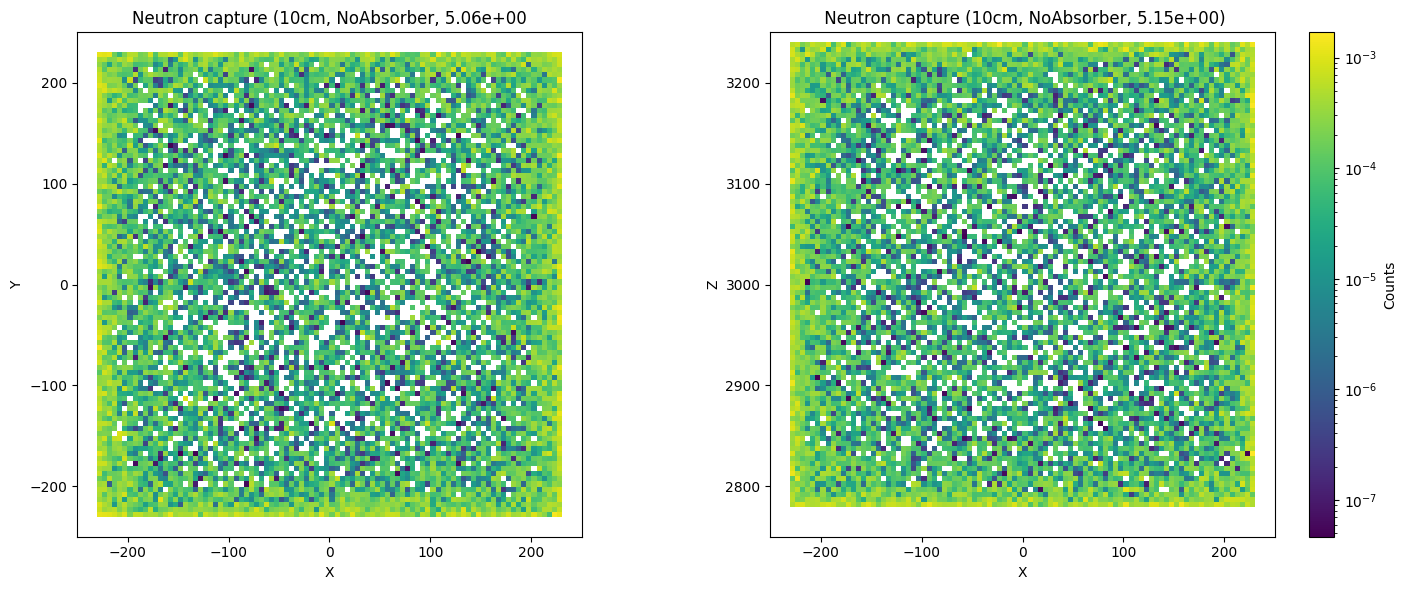

In [43]:
x_range, y_range, z_range = ranges
x_bins, y_bins, z_bins = bins_all

xy_proj = hist_xy_vals / hist_xy_vals.sum()
xz_proj = hist_xz_vals / hist_xz_vals.sum()

max_val_xy = xy_proj.max()
max_val_xz = xz_proj.max()
min_val_xy = xy_proj[xy_proj > 0].min()
min_val_xz = xz_proj[xz_proj > 0].min()
max_val = max(max_val_xy, max_val_xz)
min_val = min(min_val_xy, min_val_xz)

all_xy = hist_xy_vals.sum()
all_xz = hist_xz_vals.sum()

fig ,ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 6))

aspect = 'auto'
aspect = 'equal'

norm = mpl.colors.LogNorm(vmin=min_val, vmax=max_val) 
#norm = mpl.colors.Normalize(vmin=1, vmax=max_val*0.2)  # Use Normalize for linear scaling

ax[0].imshow(
    xy_proj.T,  
    extent=(x_range[0], x_range[1], y_range[0], y_range[1]),
    origin='lower',
    aspect=aspect,
    norm=norm
)
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].set_title(f'Neutron capture ({path_length}, {path_Material}, {all_xy:.2e}')



# XZ-Projektion (Summe über y)
ax[1].imshow(
    xz_proj.view().T,
    extent=(x_range[0], x_range[1], z_range[0], z_range[1]),
    origin='lower',
    aspect=aspect,
    norm=norm
)
ax[1].set_xlabel('X')
ax[1].set_ylabel('Z')
ax[1].set_title(f' Neutron capture ({path_length}, {path_Material}, {all_xz:.2e})')

fig.colorbar(ax[1].images[0], ax=ax[1], label='Counts')
plt.tight_layout()
plt.savefig(f"{pictures_path}/{path_Version}/{path_Material}/{path_length}/XY_XZ_Projection.png", dpi=300)
plt.show()

***
# Anderes

In [2]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
path_Version = "4_7e82d44"
path_Material = "Polyethylen25" 
path_length = "30cm"

min_data_file_size = 5 * 1024 * 1024
data_files = glob.glob(f"{data_path}/{path_Version}/{path_Material}/{path_length}/*.root")
print(f"Found {len(data_files)} files matching pattern '{path_length}' in '{data_path}/{path_Version}/{path_Material}/{path_length}/'.")

uproot_files = [{f:"events/events"} for f in data_files if os.path.getsize(f) > min_data_file_size]
print(f"Available keys in uproot files: {uproot.open(uproot_files[0]).keys()}")

Found 500 files matching pattern '30cm' in '/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/4_7e82d44/Polyethylen25/30cm/'.
Available keys in uproot files: ['eventid', 'type_pri', 'type_pri_id', 'e_pri', 'xp_pri', 'yp_pri', 'zp_pri', 'cx_pri', 'cy_pri', 'cz_pri', 'vol_pri', 'vol_pri_hash', 'NSave', 'Save_flag', 'Save_desc', 'Save_type', 'Save_x', 'Save_y', 'Save_z', 'Save_cx', 'Save_cy', 'Save_cz', 'Save_e', 'Save_t', 'Save_eventid', 'Save_trackid', 'Save_volume', 'NNAct', 'NAct_eventid', 'NAct_trackid', 'NAct_parentid', 'NAct_t', 'NAct_volume', 'NAct_volume_hash', 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_process_name', 'NAct_process_category', 'NAct_process_ID', 'NAct_particle_name', 'NAct_particle_lifetime', 'NAct_particle_id', 'NAct_particle_atomicnumber', 'NAct_particle_mass', 'NAct_particle_excitationEnergy']


In [3]:
num = 1
uproot_files = uproot_files[:num]

In [4]:
arr = uproot.dask(uproot_files, filter_name=uproot.open(uproot_files[0]).keys(), allow_missing=True, step_size="1100MB")
arr['type_pri_id'] = ak.flatten(arr['type_pri_id'])

arr = arr[arr['type_pri_id'] == 2112]
arr


dask.awkward<getitem, npartitions=2>

In [5]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}')

In [6]:
data_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data'
if not os.path.exists(f'{data_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{data_path}/{path_Version}/{path_Material}/{path_length}')

FORCE_OVERWRITE = False

## Meta-Daten und Tabellen für IDs

In [9]:
file = f"/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/{path_Version}/NoAbsorber/10cm/0.root"
rfile = uproot.open(file)

print(f"The file contains {len(rfile.keys())} keys:")
for key in rfile.keys():
    print(f"  {key}")

print(f"\nExecuted with G4VERSION {rfile['G4VERSION_TAG'].member('fTitle')}")
print(f"Total runtime: {rfile['G4RUNTIME'].member('fVal')} seconds")
print(f"Number of events: {rfile['events/nbevents'].member('fVal')}")

print(f"\nUsing the macros:")
for macro in rfile["macros"].keys():
    print(f"--> {rfile['macros'][macro].member('fName')}")
    print(f"    File content hidden for brevity ...")
    for line in rfile["macros"][macro].member('fTitle').splitlines():
        print(f"    {line}")
    print("")

The file contains 32 keys:
  G4VERSION_TAG;1
  MC_TAG;1
  MCVERSION_TAG;1
  macros;1
  macros/preinit.mac;1
  macros/det_setup.mac;1
  macros/src_neutron.mac;1
  tables;1
  tables/neutronXS_G4_AIR;1
  tables/neutronXS_G4_WATER;1
  tables/neutronXS_G4_Galactic;1
  tables/neutronXS_LXe;1
  tables/neutronXS_LXe_nA;1
  tables/neutronXS_Rock;1
  tables/neutronXS_Concrete;1
  tables/neutronXS_SS304LSteel;1
  tables/neutronXS_Paraffin;1
  tables/neutronXS_Paraffin25;1
  tables/neutronXS_Polyethylen;1
  tables/neutronXS_Polyethylen5;1
  tables/neutronXS_Polyethylen25;1
  tables/neutronXS_Polyethylen25_G4Boron;1
  tables/neutronXS_Polyethylen7Lit;1
  tables/neutronXS_Silicone5;1
  tables/neutronXS_Silicone25Lit6;1
  tables/process_subtypes;1
  tables/logical_volumes;1
  tables/physical_volumes;1
  events;1
  events/nbevents;1
  events/events;1
  G4RUNTIME;1

Executed with G4VERSION $Name: geant4-10-06-patch-02 $
Total runtime: 58175.300851059 seconds
Number of events: 4000000

Using the macros:

In [10]:
rfile = uproot.open(file)

physical_volumes = {}
for k,v in zip(*rfile["tables/physical_volumes"].arrays(library="np", how=list)):
    physical_volumes = {**physical_volumes, **{k: v for k, v in zip(k, v)}}

def get_volume_name(volume_id):
    """Get the volume name from the volume ID."""
    _hashes = {v:k for k,v in physical_volumes.items()}
    if volume_id in _hashes:
        return _hashes[volume_id]
    else:
        return f"Unknown volume ID {volume_id}"

subtypes_table = rfile["tables/process_subtypes"].arrays(library="np")

particle_ids = {}
for k,v in zip(subtypes_table['particle_id'], subtypes_table['particle_name']):
    particle_ids = {**particle_ids, **{k: v for k, v in zip(k, v)}}

def get_particle_name(particle_id):
    """Get the particle name from the particle PDG code."""
    if particle_id in particle_ids:
        return particle_ids[particle_id]
    else:
        try:
            try:
                particle = Particle.from_pdgid(particle_id)
                return particle.name
            except ParticleNotFound:
                # Check if nucleus
                if (str(particle_id)[0:2] == "10"):
                    # Remove isomeric state
                    _particle_id = int(str(particle_id)[:9] + "0")
                    particle = Particle.from_pdgid(_particle_id)
                    return particle.name+f"({str(particle_id)[9:]})"
                raise
        except Exception as e:
            return f"Unknown particle code {particle_id}"

process_subtype = {}
for k,v in zip(subtypes_table['process_subtype'], subtypes_table['process_name']):
    process_subtype = {**process_subtype, **{k: v for k, v in zip(k, v)}}

def get_process_name(process_id):
    """Get the process name from the process ID."""
    if process_id in process_subtype:
        return process_subtype[process_id]
    else:
        return f"Unknown process ID {process_id}"

In [11]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

In [12]:
processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic', 'CoulombScat']
volumes = ['Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

## NC Energydependent


In [48]:
df_pri = da.to_dataframe(arr[['e_pri']])
df = da.to_dataframe(arr[['e_pri', 'NAct_process_ID', 'NAct_volume_hash']])

### In Liquid Xenon

In [49]:
only_LXe_volume = df[df['NAct_volume_hash'] == physical_volumes['LXe']]
only_nCapture = only_LXe_volume[only_LXe_volume['NAct_process_ID'] == 131]  #nCapture
data = only_nCapture[['e_pri']]

In [50]:
bins = 101
ranges = (0,10000)

hist_pri = dh.histogram(df_pri['e_pri'], bins=bins, range=ranges)
hist = dh.histogram(data['e_pri'], bins=bins, range=ranges)

In [51]:
with ProgressBar():
    hist_pri_vals = hist_pri[0].compute()
    hist_pri_edges = hist_pri[1].compute()
    hist_vals = hist[0].compute()
    hist_edges = hist[1].compute()

[########################################] | 100% Completed | 370.83 s
[########################################] | 100% Completed | 101.10 ms
[########################################] | 100% Completed | 17m 32s
[########################################] | 100% Completed | 109.93 ms


In [52]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyNC_LXe.npz"

if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
             hist_pri_vals=hist_pri_vals, 
             hist_pri_edges=hist_pri_edges, 
             hist_vals=hist_vals, 
             hist_edges=hist_edges)
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Speichere: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen25/20cm/EnergyNC_LXe.npz


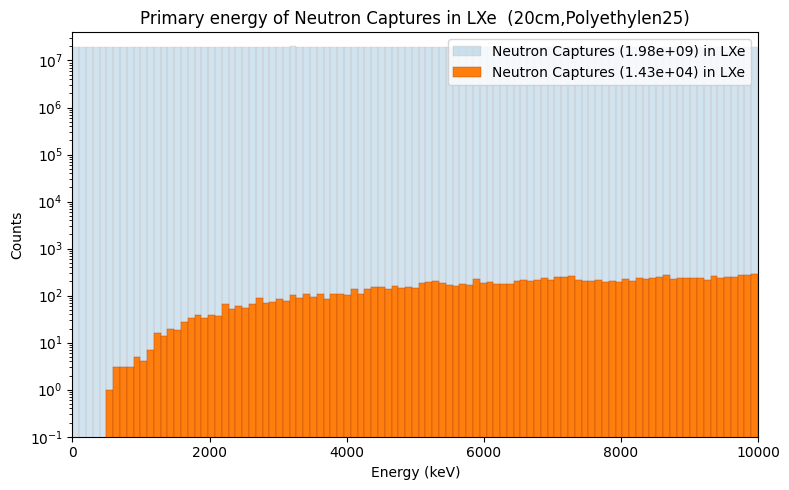

In [53]:
plt.figure(figsize=(8, 5))
plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Primary energy of Neutron Captures in LXe  ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_LXe.pdf")
plt.show()

### In Absorber

In [54]:
only_Absorber_volume = df[df['NAct_volume_hash'] == physical_volumes['Absorber']]
only_nCapture = only_Absorber_volume[only_Absorber_volume['NAct_process_ID'] == 131]  #nCapture
data = only_nCapture[['e_pri']]

In [55]:
bins = 101
ranges = (0,10000)

hist_pri = dh.histogram(df_pri['e_pri'], bins=bins, range=ranges)
hist = dh.histogram(data['e_pri'], bins=bins, range=ranges)

In [56]:
with ProgressBar():
    hist_pri_vals = hist_pri[0].compute()
    hist_pri_edges = hist_pri[1].compute()
    hist_vals = hist[0].compute()
    hist_edges = hist[1].compute()

[#############################           ] | 74% Completed | 282.81 s

[########################################] | 100% Completed | 373.77 s
[########################################] | 100% Completed | 101.12 ms
[########################################] | 100% Completed | 18m 10s
[########################################] | 100% Completed | 104.20 ms


In [57]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyNC_Absorber.npz"

if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
            hist_pri_vals=hist_pri_vals, 
            hist_pri_edges=hist_pri_edges, 
            hist_vals=hist_vals, 
            hist_edges=hist_edges)
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Speichere: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen25/20cm/EnergyNC_Absorber.npz


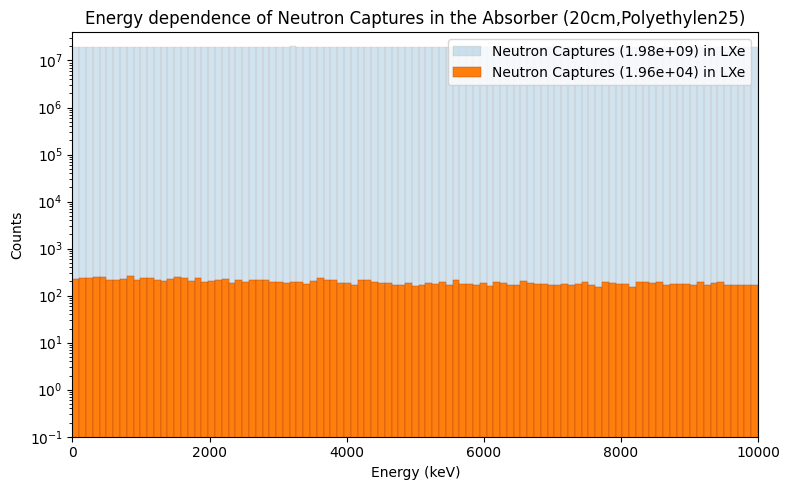

In [58]:
plt.figure(figsize=(8, 5))
plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Energy dependence of Neutron Captures in the Absorber ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_Absorber.pdf" )
plt.show()

## Processes

In [7]:
df = da.to_dataframe(arr[['e_pri', 'NAct_particle_id', 'NAct_process_ID', 'NAct_volume_hash']])

In [34]:
df_mod = df[df['NAct_particle_id'] == 1000030070]
df_mod.head()

get_process_name(121)

'xi0Inelastic'

### Xenon Volume

In [19]:
only_LXe_volume = df[df['NAct_volume_hash'] == physical_volumes['LXe']]

only_nCapture = only_LXe_volume[only_LXe_volume['NAct_process_ID'] == 131]  #nCapture

data = only_nCapture[['NAct_particle_id','NAct_process_ID']]

In [20]:
with ProgressBar():
    grouped_data = data.groupby(['NAct_particle_id','NAct_process_ID']).size().compute()


grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[0].map(lambda x: get_particle_name(x)), level = 0
)
grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[1].map(lambda x: get_process_name(x)), level = 1
)


[########################################] | 100% Completed | 6.27 ss


In [21]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Processes_LXe.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
         grouped_data_values=grouped_data.values,
         grouped_data_index_level0=grouped_data.index.get_level_values(0).values,
         grouped_data_index_level1=grouped_data.index.get_level_values(1).values)
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")


Datei bereits vorhanden, überspringe: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen25/30cm/Processes_LXe.npz


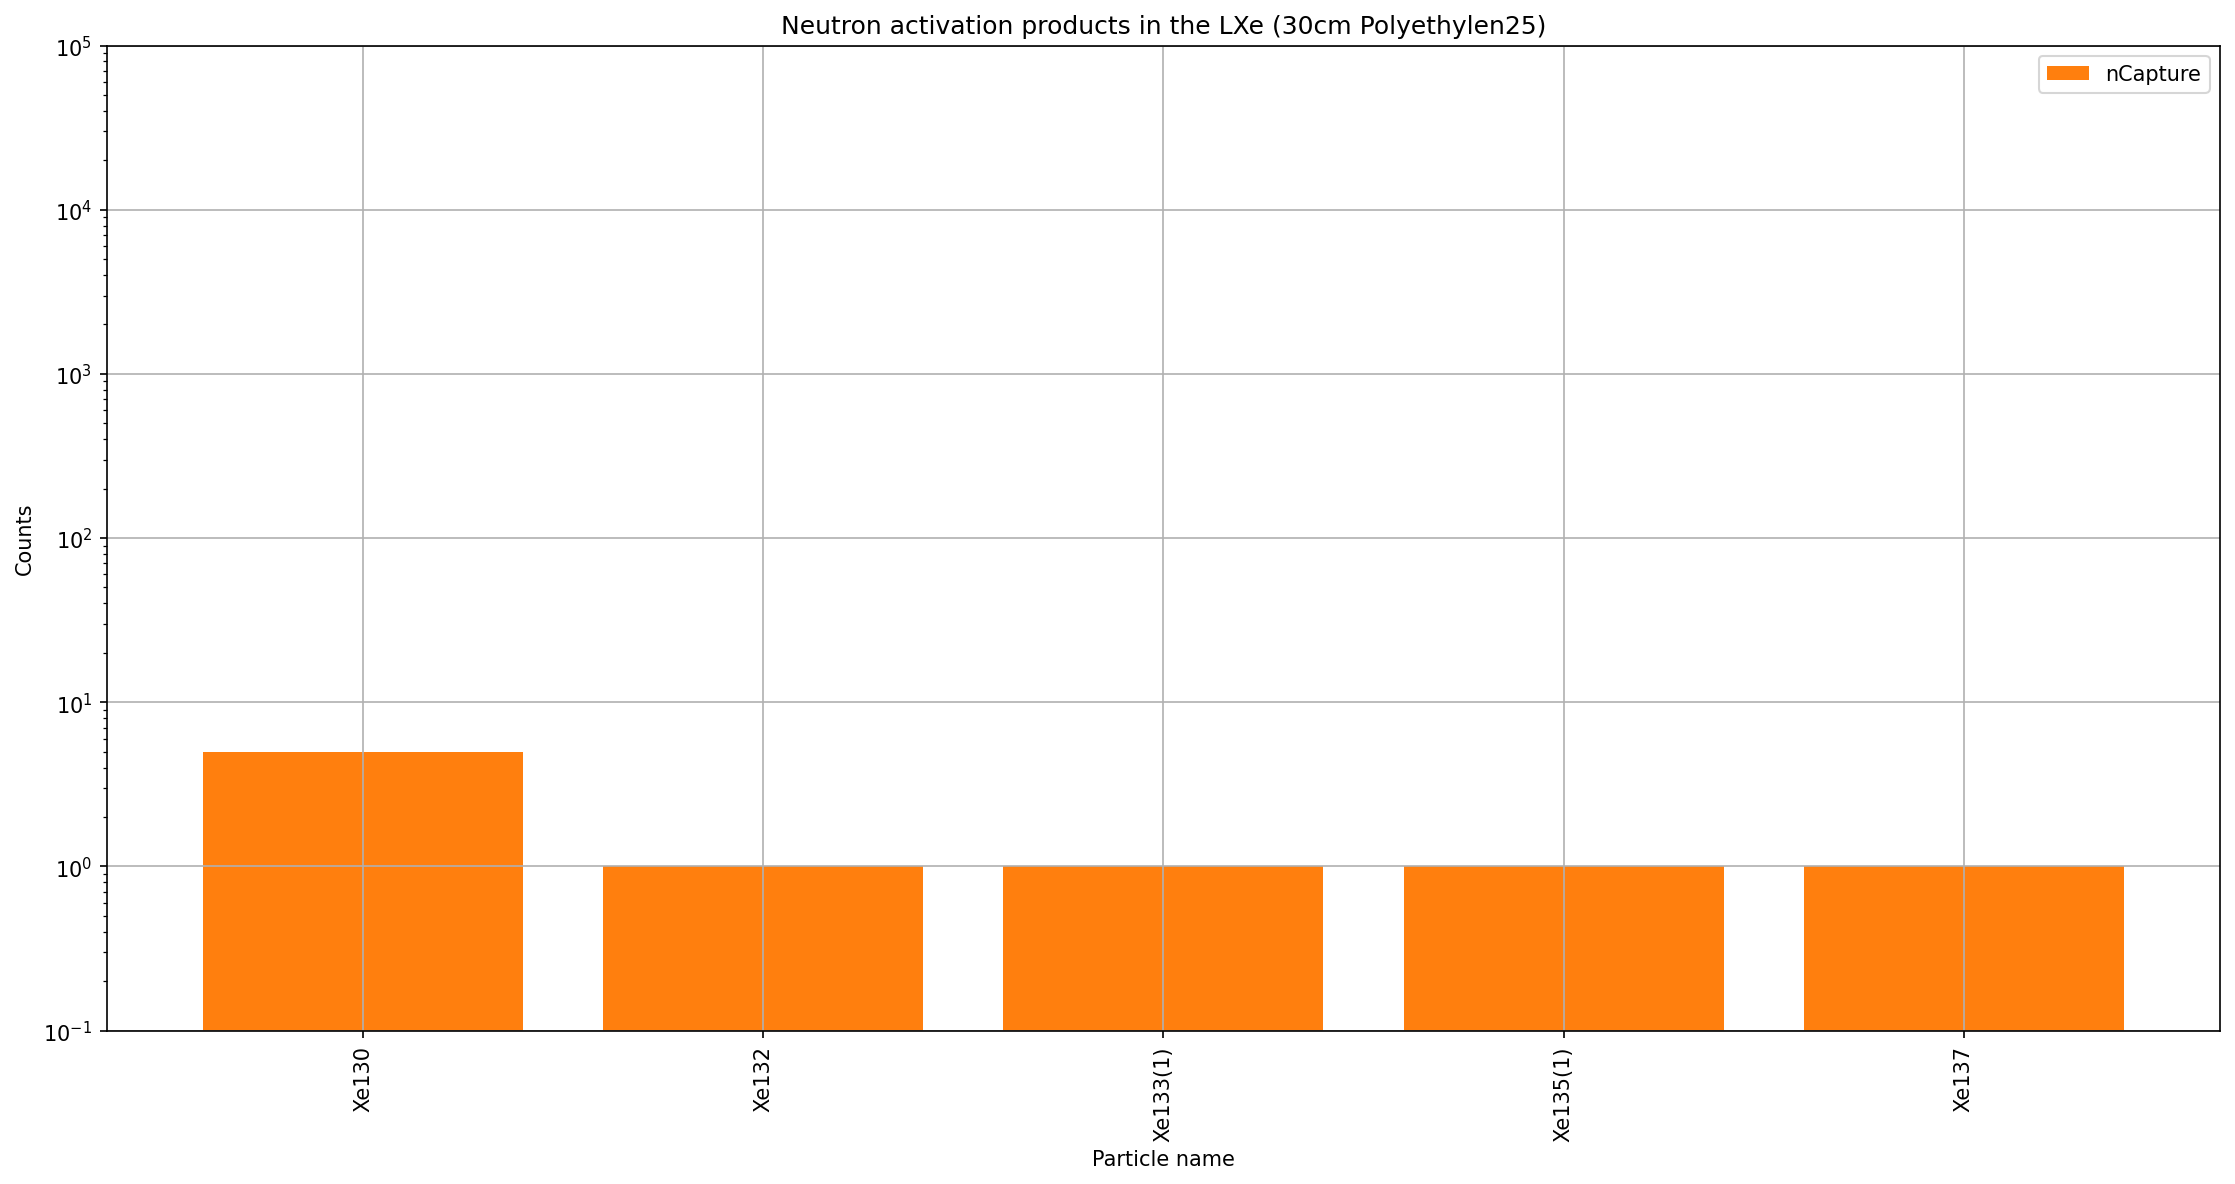

In [22]:
_data = grouped_data#[grouped_data.values > 40]

_particles = np.unique(_data.index.get_level_values(0))
_processes = np.unique(_data.index.get_level_values(1))

def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0
    
_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))
color = {pr: colors[idx % len(colors)] for idx, pr in enumerate(_processes_sorted)}


plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the LXe ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e5)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_LXe.pdf" )
plt.tight_layout()
plt.grid()

plt.show()




### Absorber Volume

In [23]:
only_Absorber_volume = df[df['NAct_volume_hash'] == physical_volumes['Absorber']]

data = only_Absorber_volume[['NAct_particle_id','NAct_process_ID']]

In [24]:
with ProgressBar():
    grouped_data = data.groupby(['NAct_particle_id','NAct_process_ID']).size().compute()


grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[0].map(lambda x: get_particle_name(x)), level = 0
)
grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[1].map(lambda x: get_process_name(x)), level = 1
)


[########################################] | 100% Completed | 3.65 ss


In [25]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
            grouped_data_values=grouped_data.values,
            grouped_data_index_level0=grouped_data.index.get_level_values(0).values,
            grouped_data_index_level1=grouped_data.index.get_level_values(1).values)
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")


Datei bereits vorhanden, überspringe: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen25/30cm/Processes_Absorber.npz


0
1
2
3
4
5


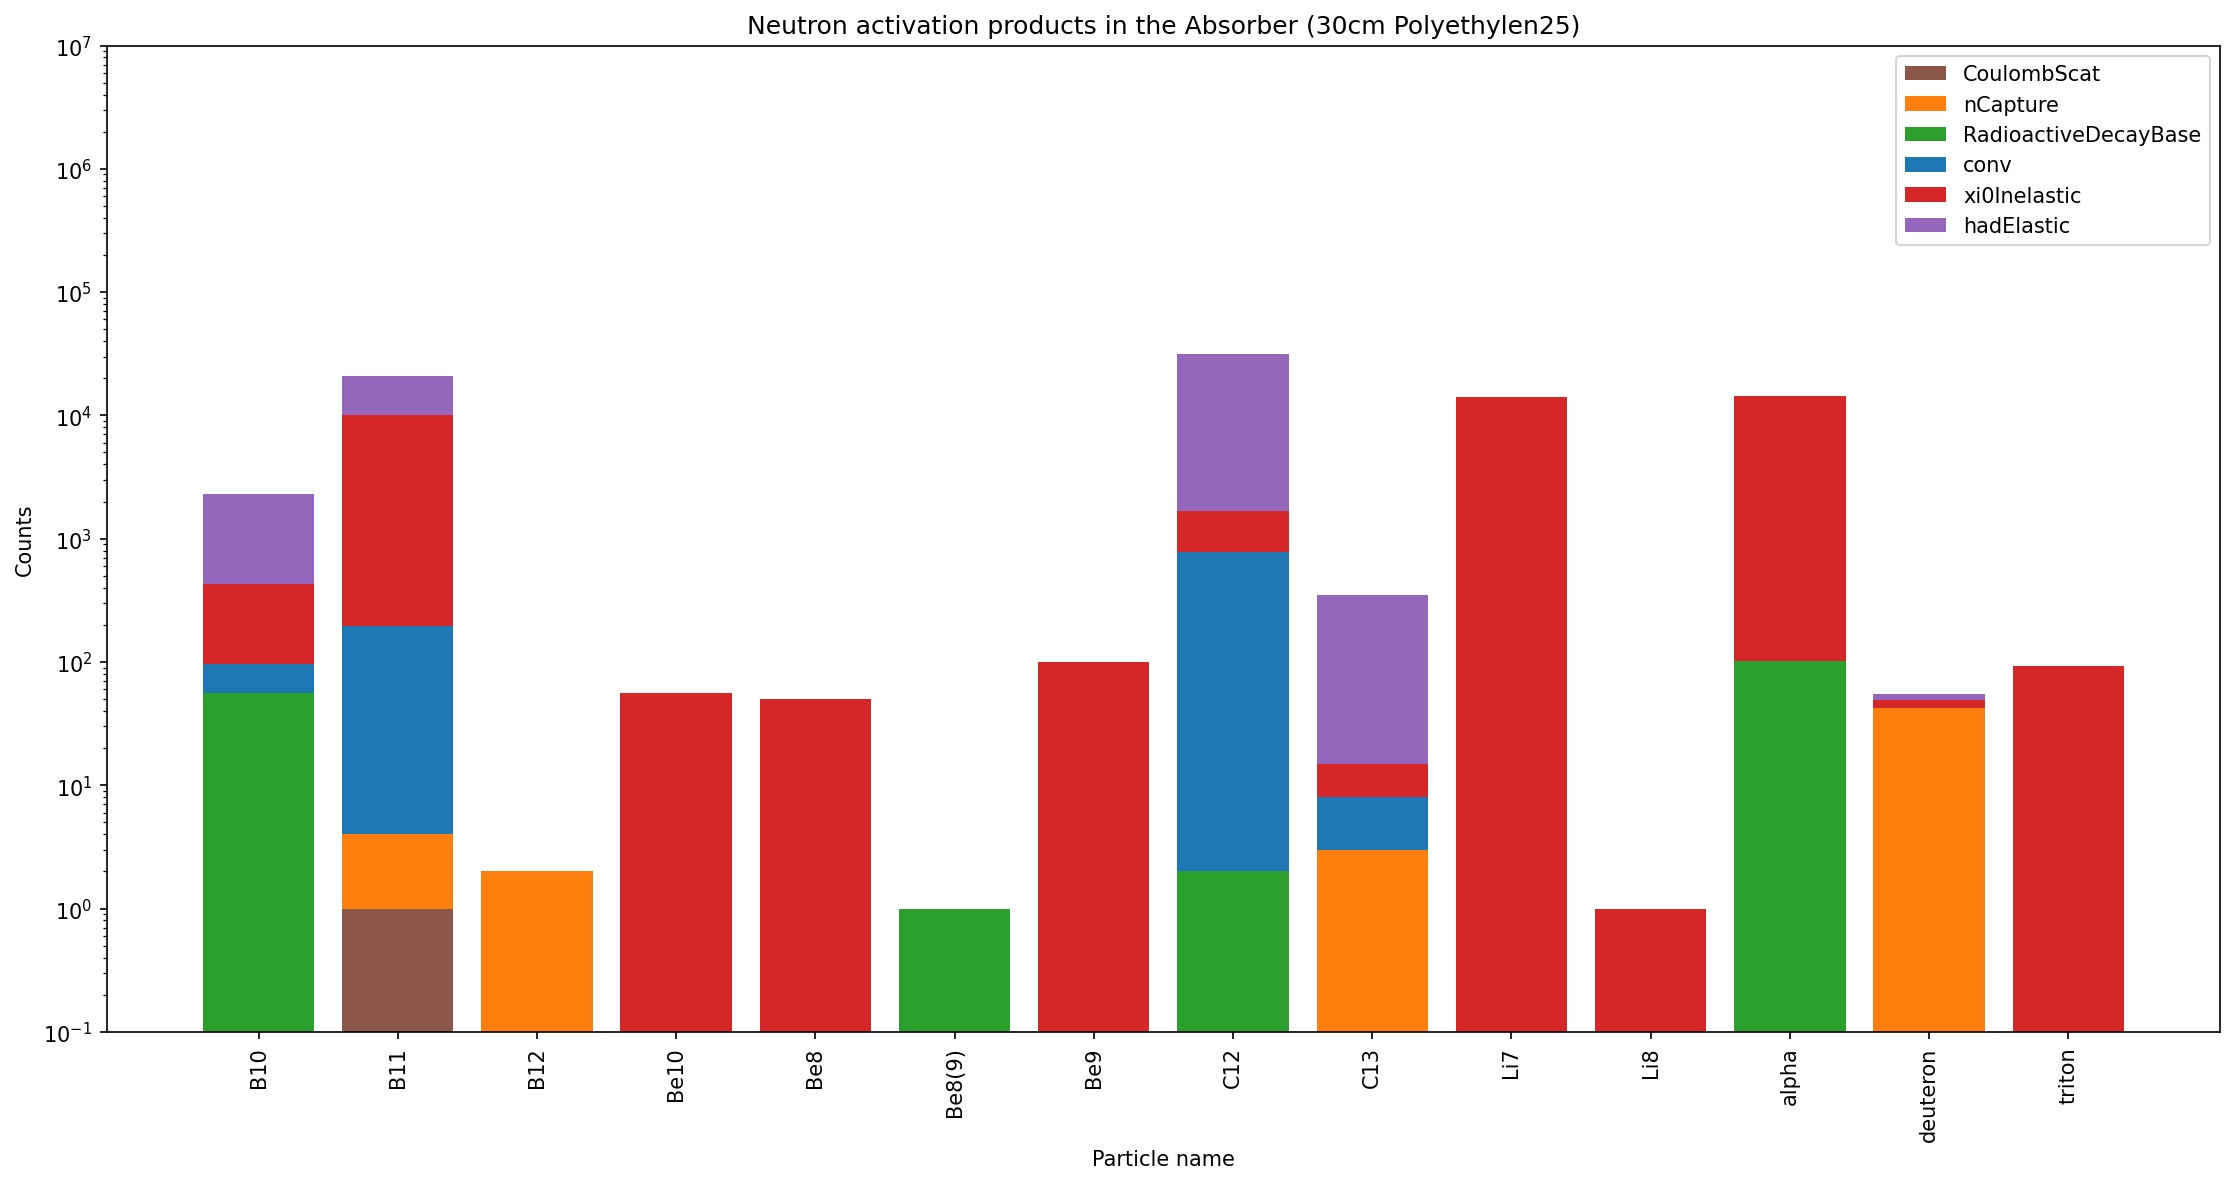

In [26]:
_data = grouped_data

_particles = np.unique(_data.index.get_level_values(0))
_processes = np.unique(_data.index.get_level_values(1))



def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0

_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))

plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    print(idx)
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the Absorber ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e7)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.pdf" )
plt.tight_layout()
plt.show()



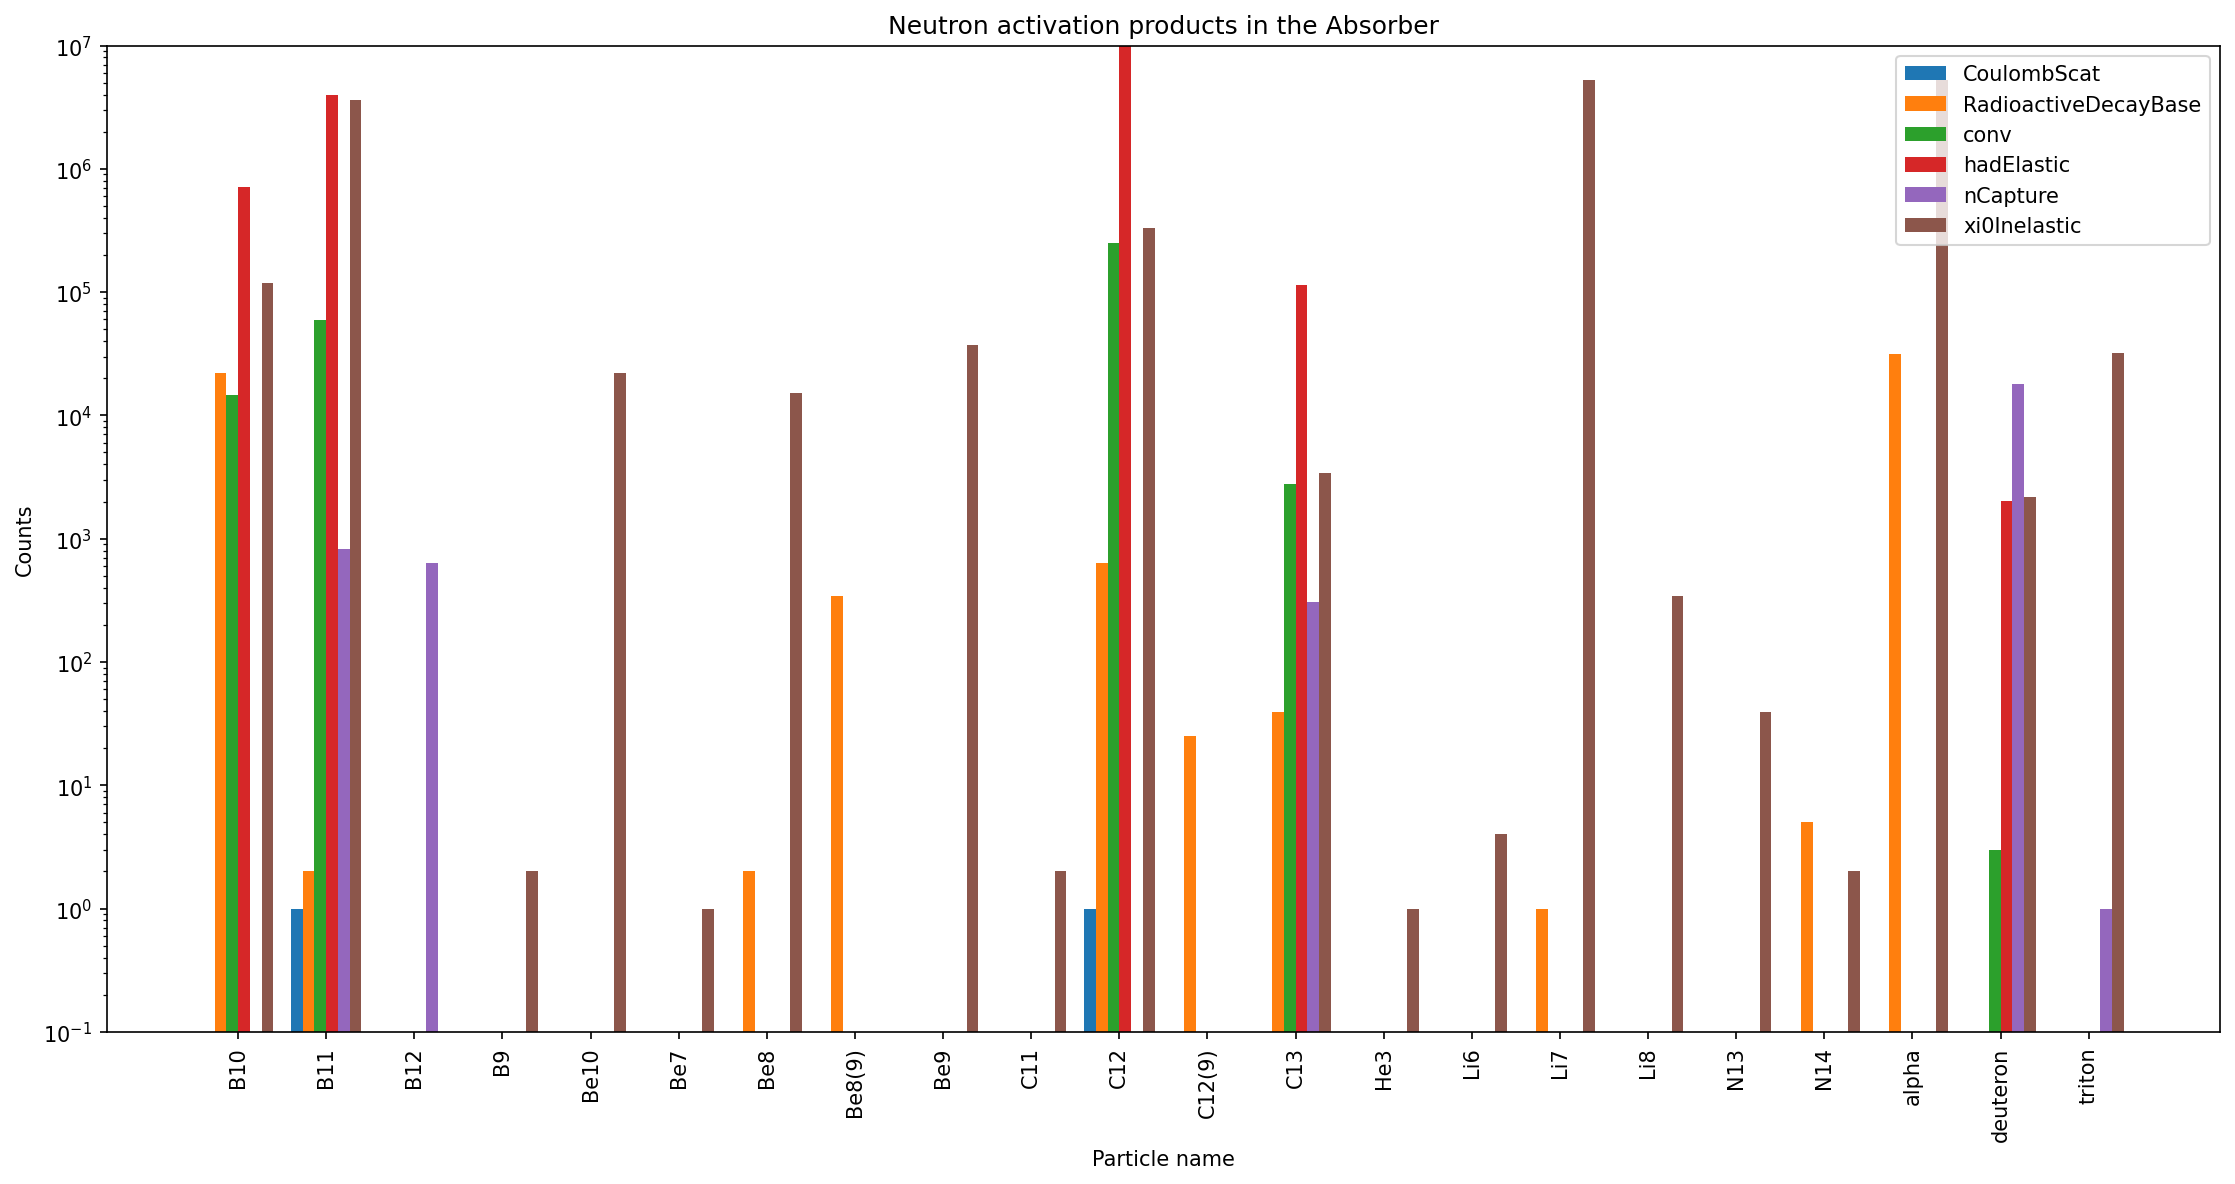

In [68]:
plt.figure(dpi=150, figsize=(15, 8))

x = np.arange(len(_particles))
bar_width = 0.8 / len(_processes)  # Balken schmaler machen, damit sie nebeneinander passen

for i, pr in enumerate(_processes):
    plt.bar(x + i * bar_width, _counts[pr], bar_width, label=pr)

ax = plt.gca()
ax.set_xticks(x + bar_width * (len(_processes)-1)/2)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the Absorber")
plt.yscale("log")
plt.ylim(0.1, 1e7)
plt.legend()
plt.tight_layout()
plt.show()

## Positions

### 2D

In [69]:
arri = arr.partitions[0:100]
df_pri = da.to_dataframe(arri[['xp_pri', 'yp_pri', 'zp_pri']])
df_NAct = da.to_dataframe(arri[[ 'NAct_x', 'NAct_y', 'NAct_z']])#, 'NAct_volume', 'NAct_process_ID']])
df_Save = da.to_dataframe(arri[['Save_x', 'Save_y', 'Save_z']])#, 'Save_volume', 'Save_desc']])


In [70]:
border = 0.1
ranges = []
coords = [['xp_pri', 'yp_pri', 'zp_pri'], ['NAct_x', 'NAct_y', 'NAct_z'], ['Save_x', 'Save_y', 'Save_z']]

ranges = [[
    (-12000, 12000),  # xp_pri
    (-16000, 16000),  # yp_pri
    (-1000, 21000)],     # zp_pri
    [(-16000, 16000),  # NAct_x
    (-16000, 16000),  # NAct_y
    (-3000, 27000)],      # NAct_z
    [(-2000, 2000),  # Save_x
    (-2000, 2000),  # Save_y
    (1000, 5000)]      # Save_z
]


""" maximum = [ranges[j][1][1]-ranges[j][1][0] for j in range(len(ranges))]
maximum_bins = 300
bins_all = [[(ranges[j][i][1]-ranges[j][i][0]) / maximum[j] * maximum_bins 
             for i in range(len(ranges[j]))] 
             for j in range(len(ranges))]

bins_all[2] = [100, 100, 100] """

#bins_all = [[50, 50, 50], [50, 50, 50], [50, 50, 50]]
bins_all = [[100, 100, 100], [100, 100, 100], [100, 100, 100]]

In [71]:
#ranges[1] = ranges[2]  # For zoom in on LXe for NAct

# Find the process code for 'nCapture'
code = [k for k, v in process_subtype.items() if v == 'nCapture']

#df_NAct = df_NAct[df_NAct['NAct_volume'] == 'LXe']
#df_NAct = df_NAct[df_NAct['NAct_process_ID'] == 131]  # nCapture
print(code)

[np.int32(131)]


In [72]:
df_pri_sample = df_pri.sample(frac=1, random_state=42)
df_NAct_sample = df_NAct.sample(frac=1, random_state=42)
df_Save_sample = df_Save.sample(frac=1, random_state=42)

dfs = [df_pri, df_NAct, df_Save]

In [73]:
h3d_computed = []
for i, coord in enumerate(coords):
    bins = [int(b) for b in bins_all[i]]
    h3d = dh.histogramdd([dfs[i][coord[0]], dfs[i][coord[1]], dfs[i][coord[2]]], bins=bins, range=ranges[i], histogram=True)
    with ProgressBar():
        h3d_computed.append(h3d.compute())

[                                        ] | 0% Completed | 255.62 us

[########################################] | 100% Completed | 43.06 s
[########################################] | 100% Completed | 144.26 s
[########################################] | 100% Completed | 53.45 s


In [74]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Positions.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
            h3d_computed=np.array(h3d_computed, dtype=object),
            coords=np.array(coords, dtype=object),
            ranges=np.array(ranges, dtype=object),
            bins_all=np.array(bins_all, dtype=object),
            allow_pickle=True)
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Speichere: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen25/20cm/Positions.npz


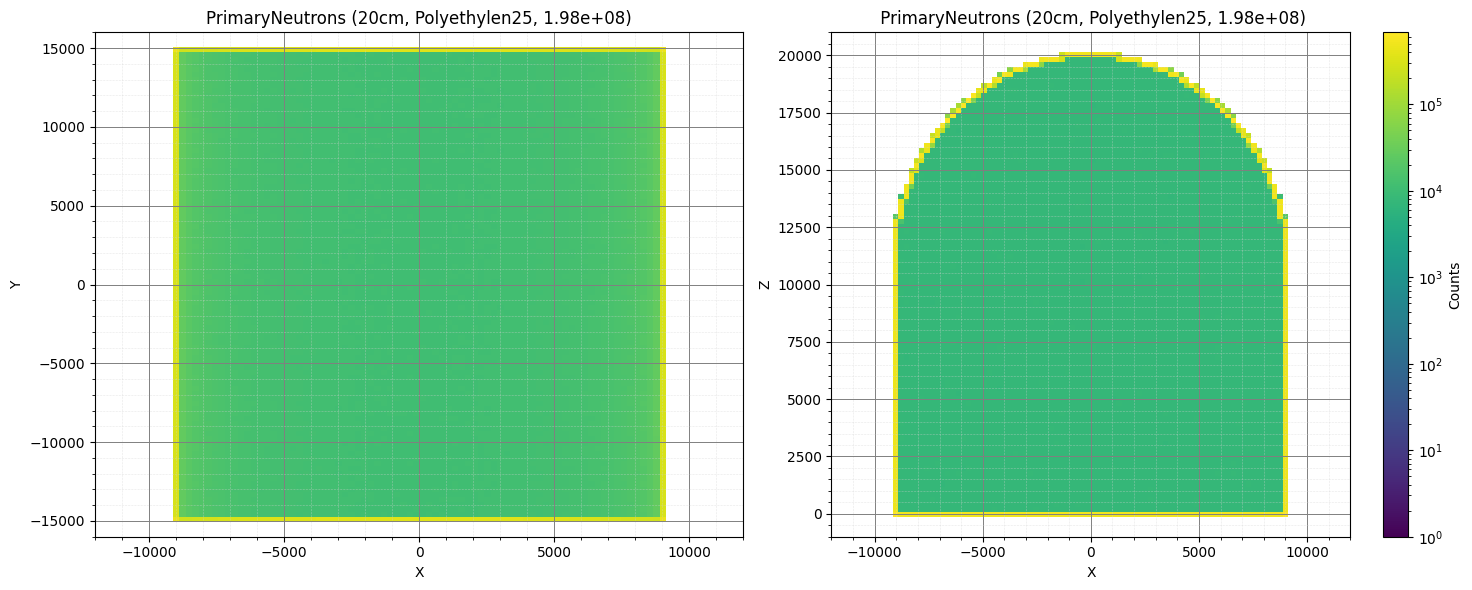

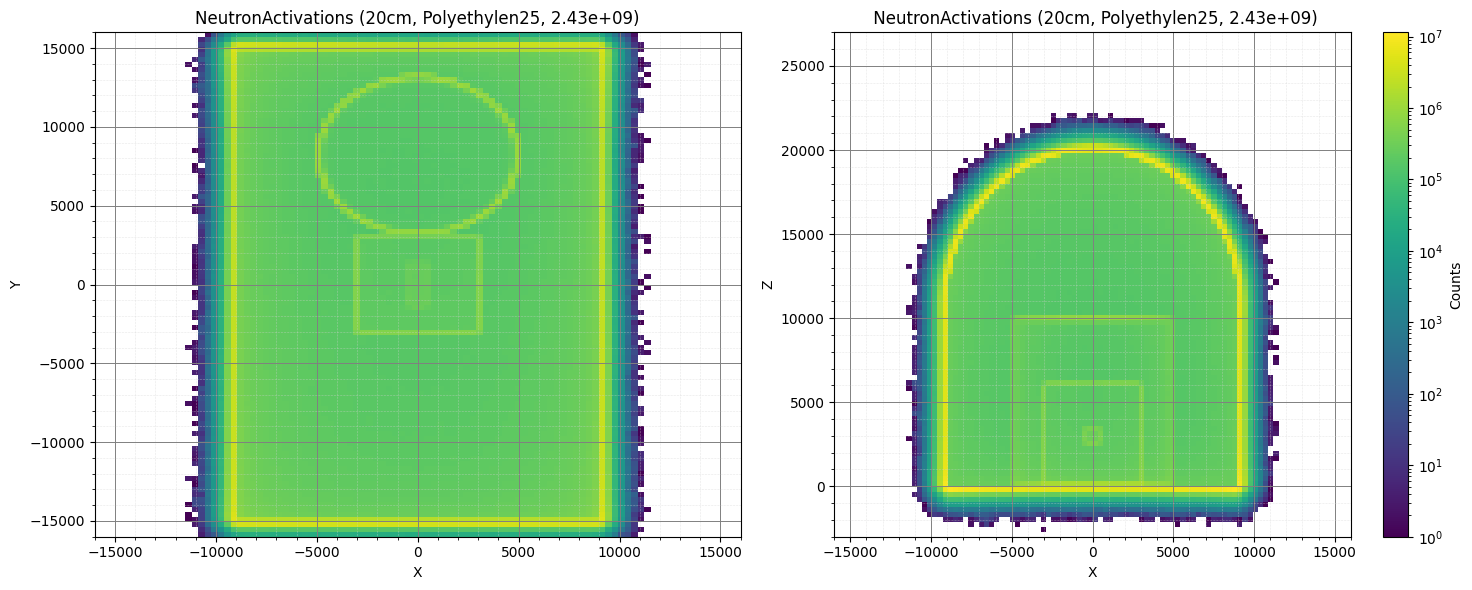

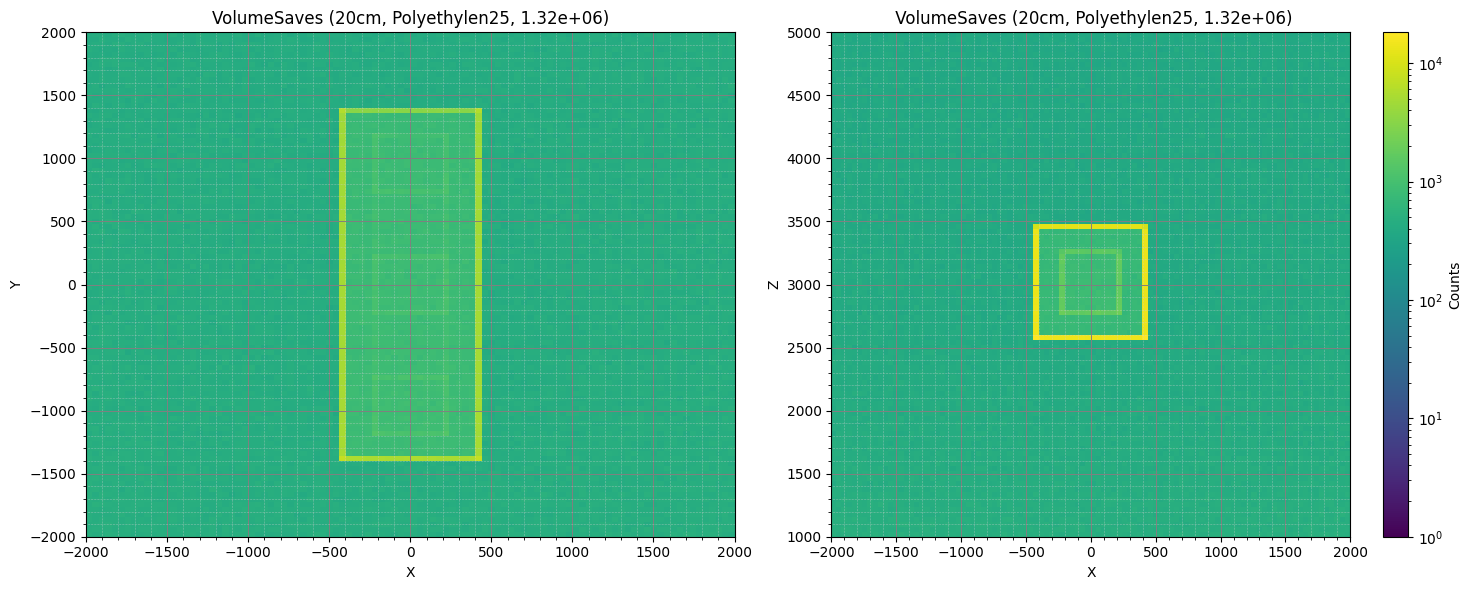

In [75]:
grid = True

for i,coord in enumerate(coords):
    if i == 0:
        a='PrimaryNeutrons'
    elif i == 1:
        a='NeutronActivations'
    elif i == 2:
        a='VolumeSaves'

    x_range, y_range, z_range = ranges[i]
    x_bins, y_bins, z_bins = bins_all[i]

    xy_proj = h3d_computed[i][:,:,sum].view()
    xz_proj = h3d_computed[i][:,sum,:].view()

    max_val = max(xy_proj.max(), xz_proj.max())
    all = h3d_computed[i].sum()

    fig ,ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 6))

    aspect = 'auto'

    norm = mpl.colors.LogNorm(vmin=1, vmax=max_val) 
    #norm = mpl.colors.Normalize(vmin=1, vmax=max_val*0.2)  # Use Normalize for linear scaling
    #aspect = 'equal'

    ax[0].imshow(
        xy_proj.T,  
        extent=(x_range[0], x_range[1], y_range[0], y_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('Y')
    ax[0].set_title(f'{a} ({path_length}, {path_Material}, {all:.2e})')



    # XZ-Projektion (Summe über y)
    ax[1].imshow(
        xz_proj.view().T,
        extent=(x_range[0], x_range[1], z_range[0], z_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('Z')
    ax[1].set_title(f' {a} ({path_length}, {path_Material}, {all:.2e})')

    if grid:
        ax[0].minorticks_on()
        ax[0].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[0].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')
        ax[1].minorticks_on()
        ax[1].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[1].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')

    fig.colorbar(ax[1].images[0], ax=ax[1], label='Counts')
    plt.tight_layout()

    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Positions_{a}.pdf" )
    plt.show()

## Energy Distributions trend

In [76]:
arr

dask.awkward<getitem, npartitions=1000>

In [77]:
arri = arr#.partitions[:100]

df_pri = da.to_dataframe(arri[['e_pri']])

df_1 = da.to_dataframe(arri[['Save_desc', 'Save_e', 'Save_volume']])
df_2 = da.to_dataframe(arri[['Save_desc', 'Save_e']])

In [78]:
labels = ['e_pri','Absorber', 'LXe', 'LXeContainer']

#df = df[df['Save_trackid'] < 5]

arrays = [df_pri[['e_pri']]]
arrays += [df_1[(df_1['Save_desc'] == "Absorber") & (df_1['Save_volume'] == 'BuildAir')]['Save_e']]
#arrays += [df[df['Save_desc'] == "AbsorberAir"]['Save_e']]
arrays += [df_2[df_2['Save_desc'] == "LXe"]['Save_e']]
arrays += [df_2[(df_2['Save_desc'] == "LXeContainer")]['Save_e']]


In [ ]:
hist_vals_list = []
bin_edges_list = []

for i in range(len(arrays)):
    #i= i +2
    hist, bin_edges = dh.histogram(arrays[i], bins=101, range=(0,10000))

    with ProgressBar():
        hist_comp = hist.compute()
        bin_edges_comp = bin_edges.compute()

    hist_vals_list.append(hist_comp)
    bin_edges_list.append(bin_edges_comp)


[########################################] | 100% Completed | 382.68 s
[########################################] | 100% Completed | 101.05 ms
[#####                                   ] | 13% Completed | 429.60 s



KeyboardInterrupt



In [ ]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
            hist_vals_list=hist_vals_list, 
            bin_edges_list=bin_edges_list,
            labels=labels)
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Speichere: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen/60cm/EnergyDistributions_Volumes.npz


0
1
3
2


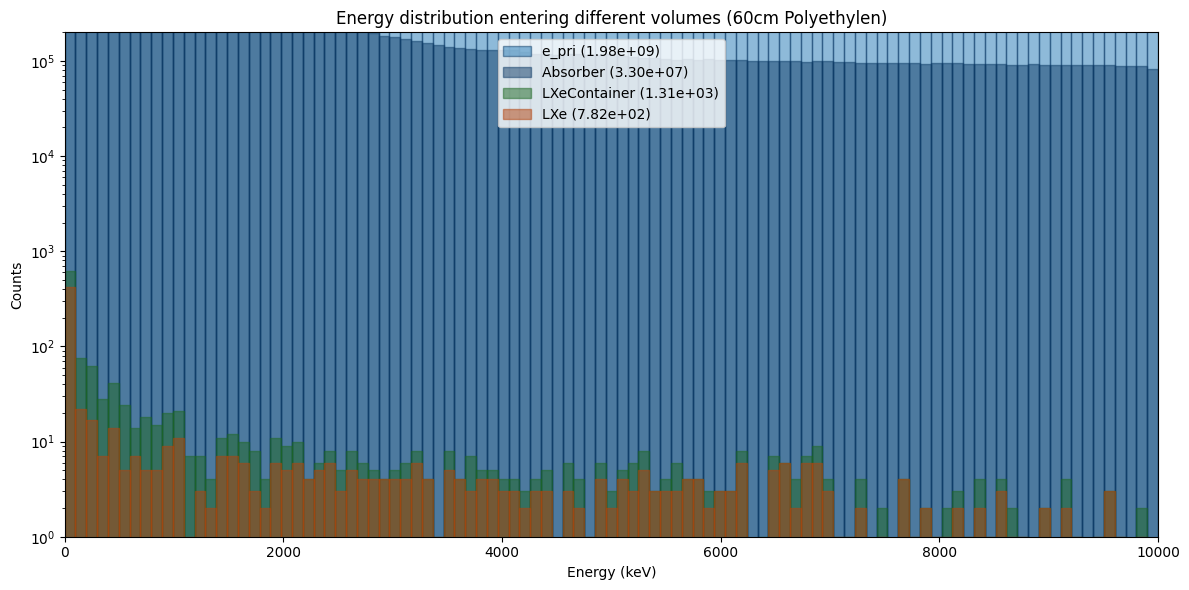

In [ ]:
plt.figure(figsize=(12, 6))

all_indices = [
    i for i in range(len(hist_vals_list))
]

# Nach Länge sortieren (absteigend)
# Sortiere die Indizes nach der Summe der Histogrammwerte
all_indices_sorted = sorted(
    all_indices,
    key=lambda i: sum(hist_vals_list[i]),
    reverse=True
)



for i in all_indices_sorted:
    print(i)
    # Use colors_Volumes and volumes only for indices 1,2,3 (since volumes has length 3)
    if i > 0 and (i-1) < len(volumes):
        bar_color = colors_Volumes[volumes[i-1]]
        bar_edge_color = colors_edges[volumes[i-1]]
    else:
        bar_color = colors[0]
        bar_edge_color = edge_colors[0] if isinstance(edge_colors, list) else colors[0]
    # Use bar_edge_color safely
    plt.bar(bin_edges_list[i][:-1], hist_vals_list[i],
            width=bin_edges_list[i][1] - bin_edges_list[i][0],
            align='edge',
            color=bar_color, edgecolor=bar_edge_color,
            label=f'{labels[i]} ({sum(hist_vals_list[i]):.2e})',
            alpha=0.5)

plt.xlim(0, 10000)

plt.yscale('log')
plt.ylim(1,2e5)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.title('Energy distribution entering different volumes ({} {})'.format(path_length, path_Material))
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.pdf" )
plt.show()

***
# Effekt of Absorber


In [22]:
df = da.to_dataframe(arr[['eventid','Save_e', 'Save_desc', 'Save_volume']])
df_abs = da.to_dataframe(arr[['eventid','Save_e', 'Save_desc', 'Save_volume']])

In [23]:
df = df[(df['Save_desc'] == 'Absorber') & (df['Save_volume'] == 'BuildAir')]
df_abs = df_abs[(df_abs['Save_volume'] == 'Absorber') & (df_abs['Save_desc'] != 'BuildAir')]

In [ ]:
df_cut = df[['eventid', 'Save_e']]
df_abs_cut = df_abs[['eventid', 'Save_e']]



In [25]:
with ProgressBar():
    df_comp = df_cut.compute()
    df_abs_comp = df_abs_cut.compute()

[########################################] | 100% Completed | 2.67 ss
[########################################] | 100% Completed | 2.52 ss


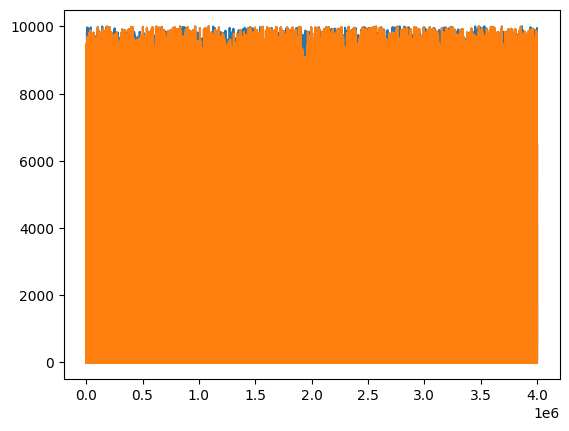

In [28]:
plt.plot(df_comp['eventid'], df_comp['Save_e'],  markersize=1, label='Absorber Air')
plt.plot(df_abs_comp['eventid'], df_abs_comp['Save_e'], markersize=1, label='Absorber')

***
# 3D Plots

## Positions

In [69]:
uprooti = uproot_files  # Limit to first 10 files for testing

da_positions = uproot.dask(uprooti, filter_name=['xp_pri', 'yp_pri', 'zp_pri','type_pri_id', 'vol_pri','NAct_volume', 'NAct_x', 'NAct_y', 'NAct_z','Save_x', 'Save_y', 'Save_z', 'Save_volume', 'Save_desc'], allow_missing=True, step_size="8GB")
da_positions['type_pri_id'] = ak.flatten(da_positions['type_pri_id'])
da_positions = da_positions[da_positions['type_pri_id'] == 2112]

df_pri = da.to_dataframe(da_positions[['xp_pri', 'yp_pri', 'zp_pri']])
df_NAct = da.to_dataframe(da_positions[[ 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_volume']])
df_Save = da.to_dataframe(da_positions[['Save_x', 'Save_y', 'Save_z', 'Save_volume', 'Save_desc']])


In [70]:
with ProgressBar():
     df_pri = df_pri.compute()
     df_NAct = df_NAct.compute()
     df_Save = df_Save.compute()

[########################################] | 100% Completed | 808.41 ms
[                                        ] | 0% Completed | 36.23 sms

KeyboardInterrupt: 

In [ ]:
frac_pri = 0.001
frac_NAct = 1
frac_Save = 0.001

df_pri_sample = df_pri.sample(frac=frac_pri, random_state=42)
df_NAct_sample = df_NAct.sample(frac=frac_NAct, random_state=42)
df_Save_sample = df_Save.sample(frac=frac_Save, random_state=42)

In [ ]:
df_NAct_sample = df_NAct_sample[(df_NAct_sample['NAct_volume'] == "LXe") ]#| (df_NAct_sample['NAct_volume'] == "Absorber") | (df_NAct_sample['NAct_volume'] == "LXeContainer")]
df_NAct_sample[['NAct_x', 'NAct_y', 'NAct_z']] = df_NAct_sample[['NAct_x', 'NAct_y', 'NAct_z']] / 1000

In [ ]:
df_Save_sample = df_Save_sample[(df_Save_sample['Save_des'] == "Absorber") & (df_Save_sample['Save_desc'] == "Absorber") ]

In [ ]:
k = 2
if(k == 0):
    x = df_pri_sample['xp_pri']
    y = df_pri_sample['yp_pri']
    z = df_pri_sample['zp_pri']
elif(k == 1):
    x = df_NAct_sample['NAct_x']
    y = df_NAct_sample['NAct_y']
    z = df_NAct_sample['NAct_z']
    # Kategorien und gewünschte Farben zuweisen
    labels = pd.Categorical(df_NAct_sample['NAct_volume']).categories
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes

    # Beispiel: Farben zuweisen (Reihenfolge wie in labels)
    custom_colors = []
    for label in labels:
        if label == "LXe":
            custom_colors.append("blue")
        elif (label == "LXeContainer") or (label == "Build") or (label == "WaterContainer"):
            custom_colors.append("green")
        elif label == "Absorber":
            custom_colors.append("orange")
        elif label == "ConcretePhysicalVolume":
            custom_colors.append("grey")
        elif label == "RockPhysicalVolume":
            custom_colors.append("black")
        elif label == "Water":
            custom_colors.append("cyan")

    labels_colors = list(zip(labels, custom_colors))
    labels_colors_sorted = sorted(labels_colors, key=lambda x: x[1])  # sortiere nach Farbe (alphabetisch)

    labels_sorted = [lc[0] for lc in labels_colors_sorted]
    colors_sorted = [lc[1] for lc in labels_colors_sorted]

    # Mapping von altem code_col zu neuem Index nach Farbsortierung
    label_to_sorted_idx = {label: i for i, label in enumerate(labels_sorted)}
    color_col_sorted = [label_to_sorted_idx[label] for label in pd.Categorical(df_NAct_sample['NAct_volume']).categories]
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes
    color_col = [label_to_sorted_idx[labels[code]] for code in color_col]
elif(k == 2):
    x = df_Save_sample['Save_x']
    y = df_Save_sample['Save_y']
    z = df_Save_sample['Save_z']
    # Kategorien und gewünschte Farben zuweisen
    labels = pd.Categorical(df_NAct_sample['NAct_volume']).categories
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes

    # Beispiel: Farben zuweisen (Reihenfolge wie in labels)
    custom_colors = []
    for label in labels:
        if label == "LXe":
            custom_colors.append("blue")
        elif (label == "LXeContainer") or (label == "Build") or (label == "WaterContainer"):
            custom_colors.append("green")
        elif label == "Absorber":
            custom_colors.append("orange")
        elif label == "ConcretePhysicalVolume":
            custom_colors.append("grey")
        elif label == "RockPhysicalVolume":
            custom_colors.append("black")
        elif label == "Water":
            custom_colors.append("cyan")

    labels_colors = list(zip(labels, custom_colors))
    labels_colors_sorted = sorted(labels_colors, key=lambda x: x[1])  # sortiere nach Farbe (alphabetisch)

    labels_sorted = [lc[0] for lc in labels_colors_sorted]
    colors_sorted = [lc[1] for lc in labels_colors_sorted]

    # Mapping von altem code_col zu neuem Index nach Farbsortierung
    label_to_sorted_idx = {label: i for i, label in enumerate(labels_sorted)}
    color_col_sorted = [label_to_sorted_idx[label] for label in pd.Categorical(df_NAct_sample['NAct_volume']).categories]
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes
    color_col = [label_to_sorted_idx[labels[code]] for code in color_col]


if k == 1 and df_NAct_sample.empty:
    print("No data to plot for Neutron Activations (df_NAct_sample is empty).")
else:
    fig = go.Figure(data=go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode='markers',
        marker=dict(
            size=2,
            color=color_col if k == 1 else None,
            colorscale=([[i/(len(colors_sorted)-1), c] for i, c in enumerate(colors_sorted)] if k == 1 and len(colors_sorted) > 0 else None),
            colorbar=(dict(
                title='NAct_volume',
                tickvals=list(range(len(labels_sorted))),
                ticktext=labels_sorted
            ) if k == 1 and len(labels_sorted) > 0 else None)
        )
    ))
    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=1000,
        height=800
    )
    fig.show()


## Directions

In [ ]:
uprooti = uproot_files[:1]  # Assuming you want the first file from the first material

da_positions = uproot.dask(uprooti, filter_name=['xp_pri', 'yp_pri', 'zp_pri','cx_pri','cy_pri','cz_pri', 'type_pri_id'], allow_missing=True, step_size="8GB")
#da_positions = uproot.dask('/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/4_7e82d44/NoAbsorber/ThreeLXeVolumes/iso_50cm_36.root:events/events', filter_name=['xp_pri', 'yp_pri', 'zp_pri','cx_pri','cy_pri','cz_pri', 'type_pri_id'], allow_missing=True, step_size="8GB")
#da_positions = uproot.dask('/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/4_7e82d44/NoAbsorber/ThreeLXeVolumes/50cm_0.root:events/events', filter_name=['xp_pri', 'yp_pri', 'zp_pri','cx_pri','cy_pri','cz_pri', 'type_pri_id'], allow_missing=True, step_size="8GB")


da_positions['type_pri_id'] = ak.flatten(da_positions['type_pri_id'])

da_positions = da_positions[da_positions['type_pri_id'] == 2112]

df_pri = da.to_dataframe(da_positions)
df = df_pri.compute()

In [ ]:
df_ed = df
#df_ed = df[df['zp_pri'] < 10]
#df_ed = df_ed[abs(df_ed['xp_pri']) < 9090]
#df_ed = df_ed[abs(df_ed['yp_pri']) < 14800]
print(df_ed.shape[0])
#df_ed = df_ed[df_ed['cz_pri'] < 0]
df_ed

In [ ]:
# Wir nehmen 1/100000 der Daten aus df_ed für die 3D-Visualisierung
df_sample = df_ed.sample(frac=1/10, random_state=42)

# Richtungsvektoren
u = df_sample['cx_pri'].values
v = df_sample['cy_pri'].values
w = df_sample['cz_pri'].values


fig = go.Figure(data=go.Cone(
    x=df_sample['xp_pri'].values,
    y=df_sample['yp_pri'].values,
    z=df_sample['zp_pri'].values,
    u=u,
    v=v,
    w=w,
    colorscale='hsv',
    sizemode="absolute",
    sizeref=30,
    showscale=True,
    colorbar=dict(title='Azimutwinkel (phi)'),
))
fig.update_layout(
    scene=dict(
        xaxis_title='xp_pri',
        yaxis_title='yp_pri',
        zaxis_title='zp_pri'
    ),
    width=900,
    height=700,
    title='3D-Coneplot: Farbe = Richtung (Azimutwinkel)'
)
fig.show()